## ABC Analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   


df = pd.read_csv("inventory_data.csv")
print(df.head(10))

    Item_ID  Annual_Demand  Unit_Cost  Annual_Consumption
0  ITEM_001            910     328.56           298989.60
1  ITEM_002           3822     730.96          2793729.12
2  ITEM_003           3142     639.37          2008900.54
3  ITEM_004            516     887.78           458094.48
4  ITEM_005           4476     474.85          2125428.60
5  ITEM_006           3494     124.00           433256.00
6  ITEM_007           3221     714.68          2301984.28
7  ITEM_008           2969     761.98          2262318.62
8  ITEM_009            180     563.47           101424.60
9  ITEM_010           1735     772.11          1339610.85


### ABC Classification Function

In [2]:
df = df.sort_values(by = "Annual_Consumption", ascending=False).reset_index(drop=True)
# df.head()
df["Cumulative_Consumption"] = (df["Annual_Consumption"].cumsum()).round(2)

total_consumption = df["Annual_Consumption"].sum()
#print(f"Total Annual Consumption: {total_consumption}")
df["Cumulative_Percentage"] = ((df["Cumulative_Consumption"] / total_consumption) * 100).round(2)
#df.tail()  
def abc_classifier(row):
    if row['Cumulative_Percentage'] <= 80:
        return "A"
    elif row['Cumulative_Percentage'] <= 95:
        return "B"
    else:
        return "C"
    
df["Category"] = df.apply(abc_classifier, axis=1)
print(df.head(10))

    Item_ID  Annual_Demand  Unit_Cost  Annual_Consumption  \
0  ITEM_070           4601     985.72          4535297.72   
1  ITEM_098           4648     925.07          4299725.36   
2  ITEM_056           3993     962.64          3843821.52   
3  ITEM_036           3940     808.40          3185096.00   
4  ITEM_077           4937     634.14          3130749.18   
5  ITEM_030           4708     635.24          2990709.92   
6  ITEM_090           4564     646.95          2952679.80   
7  ITEM_094           3149     937.05          2950770.45   
8  ITEM_034           3252     893.10          2904361.20   
9  ITEM_002           3822     730.96          2793729.12   

   Cumulative_Consumption  Cumulative_Percentage Category  
0              4535297.72                   3.73        A  
1              8835023.08                   7.27        A  
2             12678844.60                  10.43        A  
3             15863940.60                  13.05        A  
4             18994689.78   

### ABC Inventory Analysis (Pareto Classification)

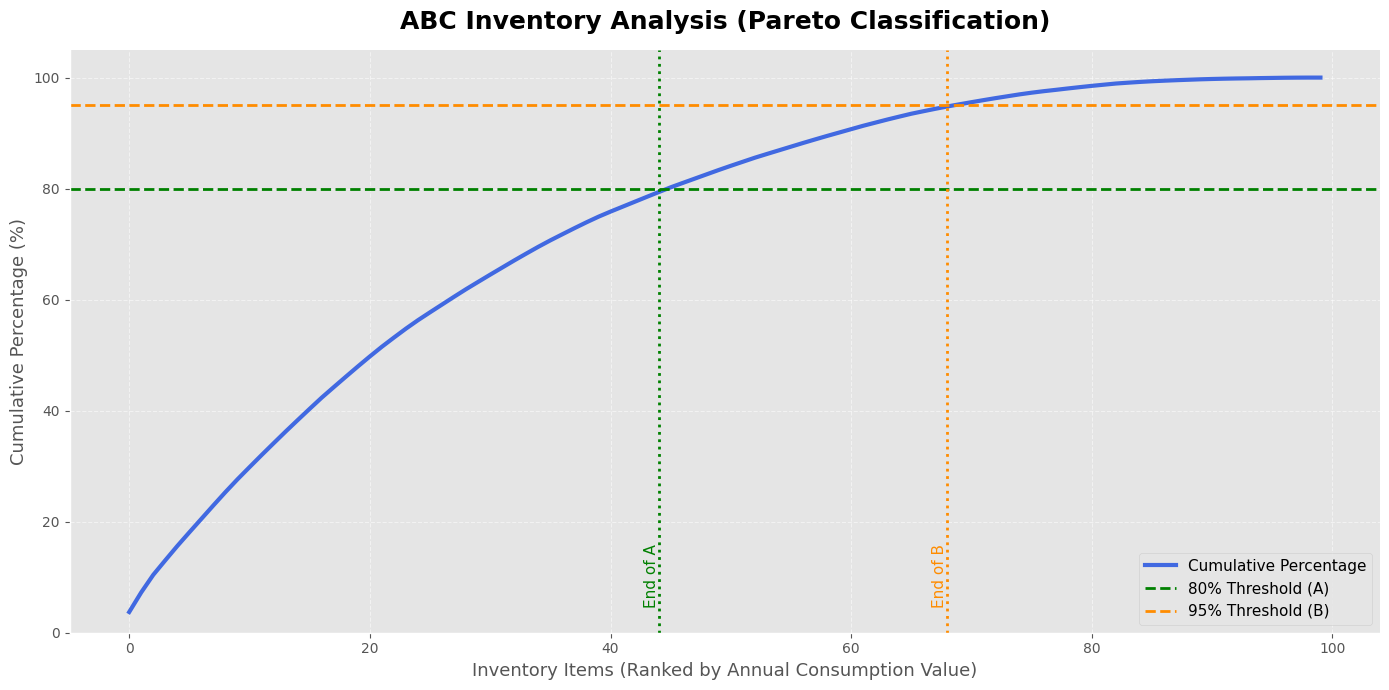

In [3]:
a_end = df[df["Category"] == "A"].index.max()
b_end = df[df["Category"] == "B"].index.max()

plt.style.use("ggplot")          # Professional style

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    df.index,
    df["Cumulative_Percentage"],
    color="royalblue",
    linewidth=3,
    label="Cumulative Percentage"
)

ax.axhline(
    80,
    color="green",
    linestyle="--",
    linewidth=2,
    label="80% Threshold (A)"
)

ax.axhline(
    95,
    color="darkorange",
    linestyle="--",
    linewidth=2,
    label="95% Threshold (B)"
)

ax.axvline(
    a_end,
    color="green",
    linestyle=":",
    linewidth=2
)

ax.axvline(
    b_end,
    color="darkorange",
    linestyle=":",
    linewidth=2
)

ax.text(a_end, 5, "End of A",
        rotation=90,
        color="green",
        fontsize=11,
        ha="right")

ax.text(b_end, 5, "End of B",
        rotation=90,
        color="darkorange",
        fontsize=11,
        ha="right")

ax.set_title(
    "ABC Inventory Analysis (Pareto Classification)",
    fontsize=18,
    weight="bold",
    pad=15
)

ax.set_xlabel(
    "Inventory Items (Ranked by Annual Consumption Value)",
    fontsize=13
)

ax.set_ylabel(
    "Cumulative Percentage (%)",
    fontsize=13
)
ax.set_ylim(0, 105)
ax.grid(True, linestyle="--", alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=True, fontsize=11)
plt.tight_layout()
plt.savefig(
    "ABC_Analysis.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

### Distribution of Inventory Items Across ABC Categories

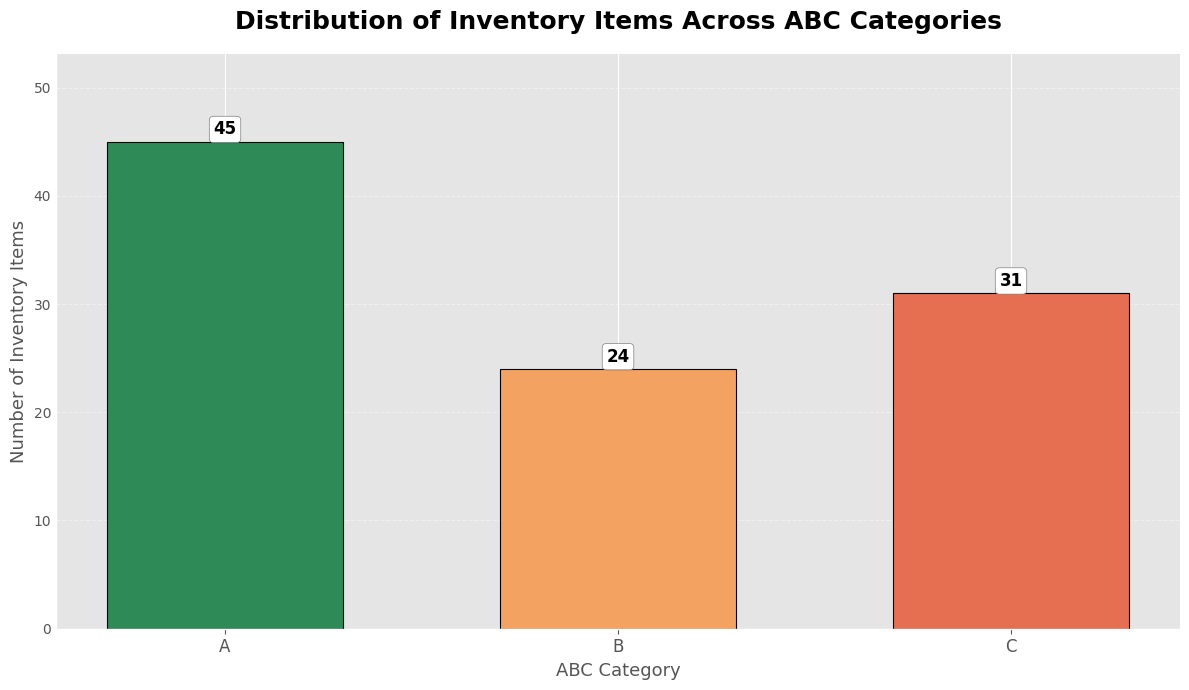

In [4]:


# -------------------------------------
# Count items in each ABC Category
# -------------------------------------
counts = (
    df["Category"]
    .value_counts()
    .reindex(["A", "B", "C"])
)

# -------------------------------------
# Plot Settings
# -------------------------------------
plt.style.use("ggplot")

fig, ax = plt.subplots(figsize=(12, 7))

# Professional colors
colors = ["#2E8B57", "#F4A261", "#E76F51"]

bars = ax.bar(
    counts.index,
    counts.values,
    color=colors,
    width=0.6,
    edgecolor="black",
    linewidth=0.8
)

# -------------------------------------
# Add Value Labels
# -------------------------------------
for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="gray",
            boxstyle="round,pad=0.25"
        )
    )

# -------------------------------------
# Labels & Title
# -------------------------------------
ax.set_title(
    "Distribution of Inventory Items Across ABC Categories",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "ABC Category",
    fontsize=13
)

ax.set_ylabel(
    "Number of Inventory Items",
    fontsize=13
)

# -------------------------------------
# Grid
# -------------------------------------
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# -------------------------------------
# Remove unnecessary spines
# -------------------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Remove tick marks but keep labels
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", labelsize=12)

# Add some headroom for annotations
ax.set_ylim(0, counts.max() * 1.18)

# -------------------------------------
# Save High Quality Image
# -------------------------------------
plt.tight_layout()

plt.savefig(
    "ABC_Category_Distribution.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

### Annual Inventory Value by ABC Category

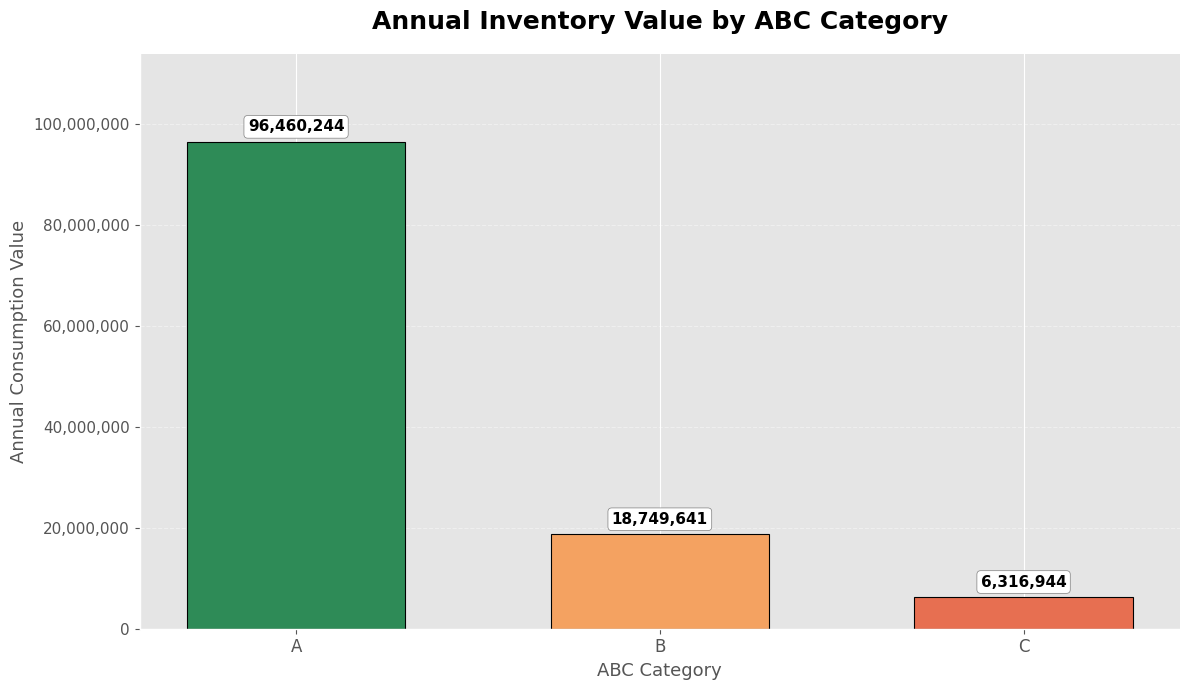

In [5]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

# -------------------------------------
# Total Annual Consumption by Category
# -------------------------------------
value = (
    df.groupby("Category")["Annual_Consumption"]
      .sum()
      .reindex(["A", "B", "C"])
)

# -------------------------------------
# Plot Settings
# -------------------------------------
plt.style.use("ggplot")

fig, ax = plt.subplots(figsize=(12, 7))

# Professional ABC colors
colors = ["#2E8B57", "#F4A261", "#E76F51"]

bars = ax.bar(
    value.index,
    value.values,
    color=colors,
    width=0.6,
    edgecolor="black",
    linewidth=0.8
)

# -------------------------------------
# Format Y-axis with commas
# -------------------------------------
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# -------------------------------------
# Value Labels
# -------------------------------------
for bar in bars:

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + value.max()*0.015,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="gray",
            boxstyle="round,pad=0.25"
        )
    )

# -------------------------------------
# Labels & Title
# -------------------------------------
ax.set_title(
    "Annual Inventory Value by ABC Category",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "ABC Category",
    fontsize=13
)

ax.set_ylabel(
    "Annual Consumption Value",
    fontsize=13
)

# -------------------------------------
# Grid
# -------------------------------------
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# -------------------------------------
# Remove extra borders
# -------------------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=11)

# -------------------------------------
# Add some headroom
# -------------------------------------
ax.set_ylim(0, value.max()*1.18)

# -------------------------------------
# Save High Resolution
# -------------------------------------
plt.tight_layout()

plt.savefig(
    "ABC_Inventory_Value.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [7]:
summary = df.groupby('Category')['Annual_Consumption'].sum().reset_index()

# summary.head()

total_sum = summary['Annual_Consumption'].sum()
summary['Percentage_of_Total'] = ((summary['Annual_Consumption'] /total_sum) *100 ).round(2)
summary['Percentage_of_Total'] = summary['Percentage_of_Total'].astype(str) + "%"
print(summary)

  Category  Annual_Consumption Percentage_of_Total
0        A         96460244.07              79.37%
1        B         18749640.98              15.43%
2        C          6316943.60                5.2%
